(np.float64(-0.5), np.float64(15.5), np.float64(15.5), np.float64(-0.5))

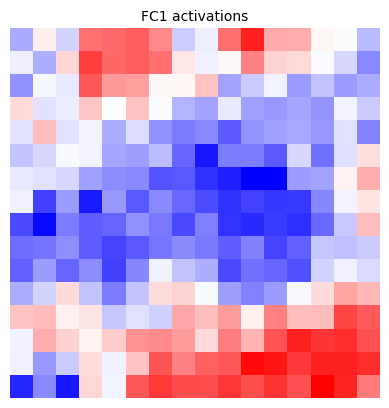

In [11]:
import os
import torch

def retrieve_raw_heatmaps(model_name):
    prefix = "../save/ResNet18/figures/actmaps/"
    trials_path = os.path.join(prefix, model_name)

    results = {}
    # List all directories inside trials_path
    for trial_dir in os.listdir(trials_path):
        if trial_dir.startswith('trial_'):
            # Extract integer after 'trial_'
            try:
                trial_num = int(trial_dir.split('_')[1])
            except ValueError:
                continue  # In case of unexpected directory names
            pt_path = os.path.join(trials_path, trial_dir, "e2e_best.pt")
            if os.path.isfile(pt_path):
                results[trial_num] = torch.load(pt_path)
    return results
model_name = "crossentropy_wstopo_256embdims_0.04rho_50epochs_512bsz_2nwork_0.002lr_0.5dropout"

dicts = retrieve_raw_heatmaps(model_name)

trucks_only = {k: v['truck'] for k, v in dicts.items() if 'truck' in v}

import matplotlib.pyplot as plt

plt.imshow(
                trucks_only[0],
                cmap='bwr',
                interpolation='nearest',
                # vmin=-v,
                # vmax=v,
            )
plt.title("FC1 activations", fontsize=10)
plt.axis('off')